# 1. The Implicit Method: Step-by-Step

To solve the Black-Scholes model numerically, we have to translate
continuous calculus into discrete algebra.

We start with the fundamental Black-Scholes Partial Differential
Equation (PDE):
$$ \frac{\partial V}{\partial t} + rS \frac{\partial V}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - rV = 0 $$

Our goal is to solve for $V(S, t)$, which represents the fair price of
the option at a specific stock price $S$ and time $t$.

## Step 1: Setting up the Grid and Variables

Instead of continuous time and price, we chop the world into a finite
grid.

-   Let the vertical axis be the Stock Price ($S$), broken into steps of
    size $\Delta S$. We use the index $i$ to denote our row (so
    $S = i\Delta S$).
-   Let the horizontal axis be Time ($t$), broken into steps of size
    $\Delta t$. We use the index $j$ to denote our column.
-   $V_i^j$ represents the unknown price of the option *today* at stock
    price node $i$ and time node $j$.
-   $V_i^{j+1}$ represents the known price of the option *tomorrow* (the
    future time step).

Because we only know the intrinsic value of the option at expiration, we
must start at the right side of the grid and step backward to the left.

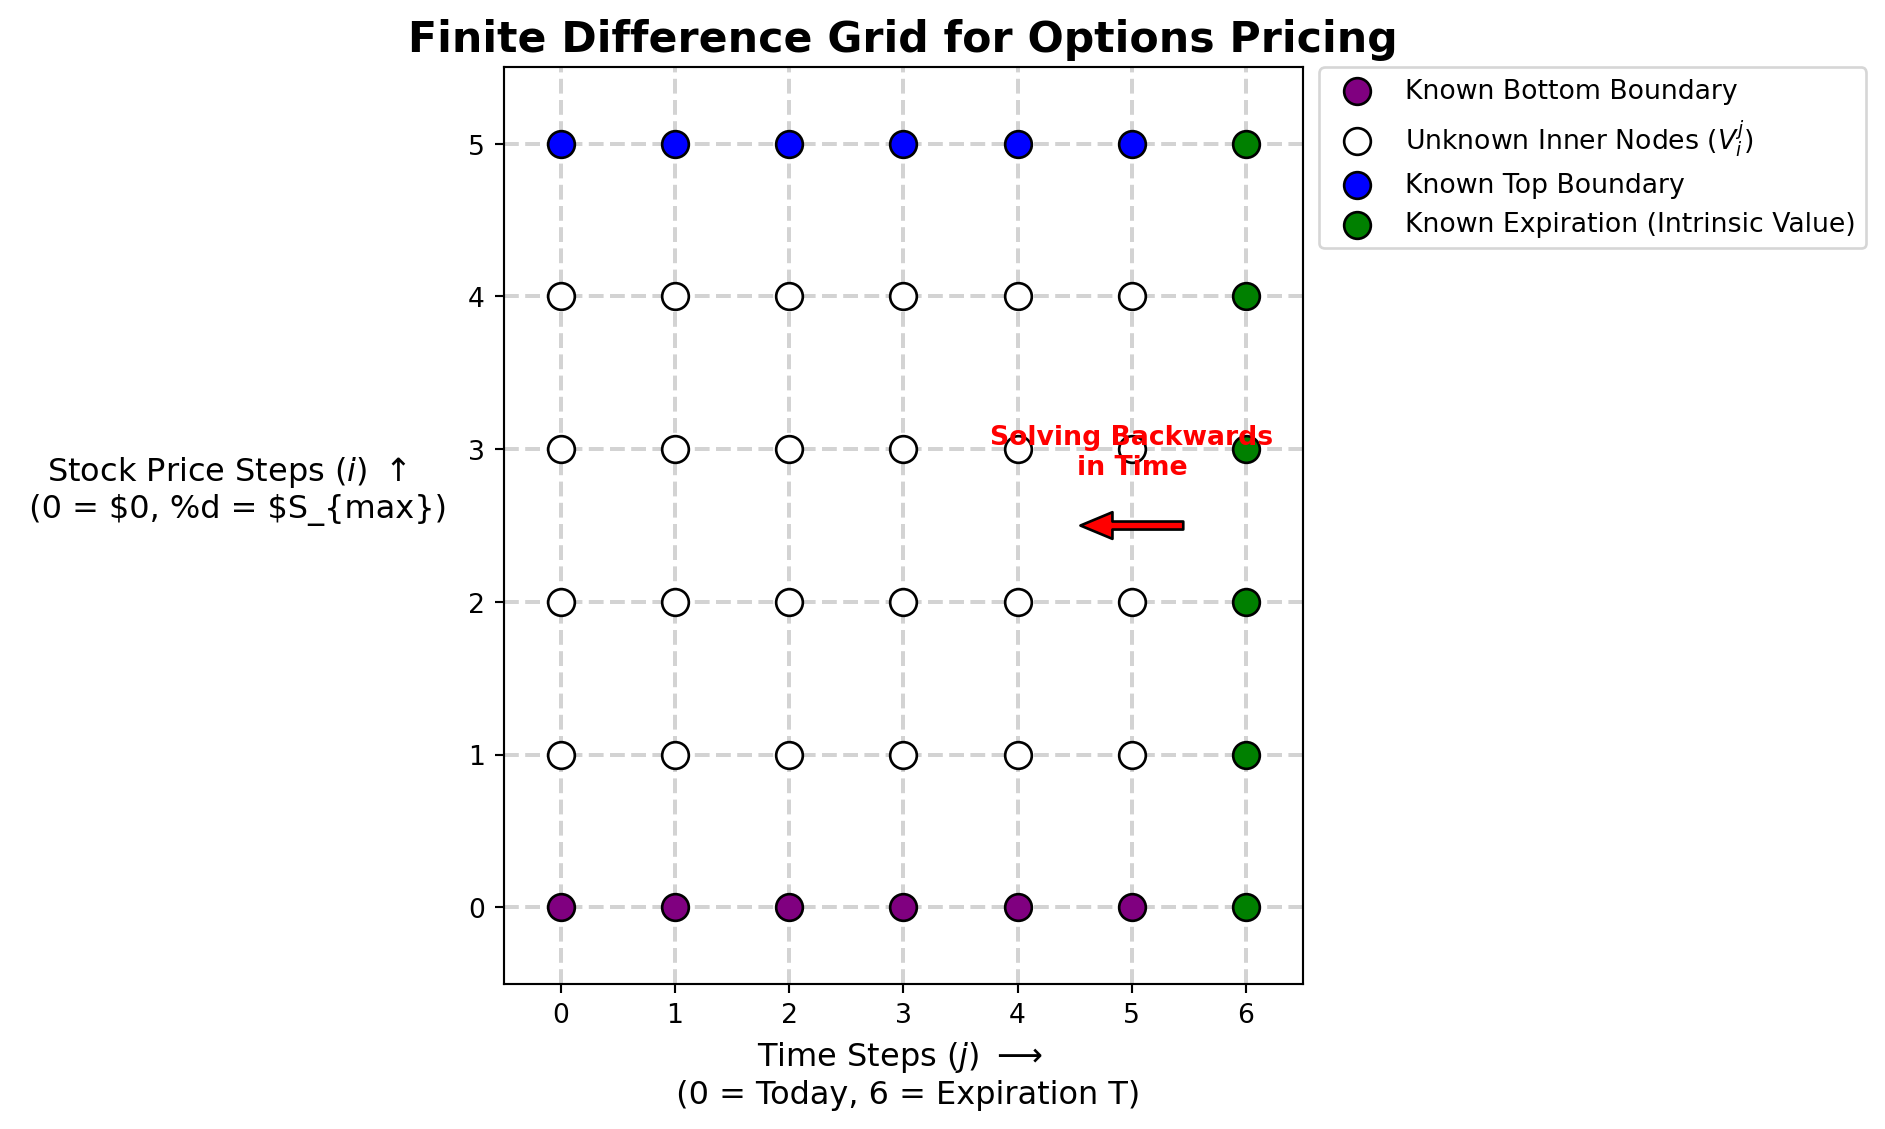

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grid Dimensions for the plot (Keep it small for a clean diagram)
N_time = 6   # Number of time steps (j)
M_price = 5  # Number of stock price steps (i)

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Draw the grid lines
for i in range(M_price + 1):
    ax.axhline(y=i, color='lightgray', linestyle='--', zorder=1)
for j in range(N_time + 1):
    ax.axvline(x=j, color='lightgray', linestyle='--', zorder=1)

# 3. Plot the nodes
for j in range(N_time + 1):
    for i in range(M_price + 1):
        
        # Condition 1: Expiration Payoff (The far right column)
        if j == N_time:
            ax.scatter(j, i, color='green', s=100, zorder=2, edgecolors='black', label='Known Expiration (Intrinsic Value)' if i==0 else "")
            
        # Condition 2: Top Boundary (Max Stock Price)
        elif i == M_price:
            ax.scatter(j, i, color='blue', s=100, zorder=2, edgecolors='black', label='Known Top Boundary' if j==0 else "")
            
        # Condition 3: Bottom Boundary (Zero Stock Price)
        elif i == 0:
            ax.scatter(j, i, color='purple', s=100, zorder=2, edgecolors='black', label='Known Bottom Boundary' if j==0 else "")
            
        # Condition 4: Inner Nodes (The unknowns we are solving for)
        else:
            ax.scatter(j, i, color='white', s=100, zorder=2, edgecolors='black', label='Unknown Inner Nodes ($V_i^j$)' if i==1 and j==0 else "")

# 4. Add an arrow to show the direction of time-stepping
ax.annotate('', xy=(N_time - 1.5, M_price / 2), xytext=(N_time - 0.5, M_price / 2),
            arrowprops=dict(facecolor='red', shrink=0.05, width=3, headwidth=10))
ax.text(N_time - 1, (M_price / 2) + 0.3, "Solving Backwards\nin Time", 
        color='red', ha='center', va='bottom', fontweight='bold')

# 5. Labels and Formatting
ax.set_title("Finite Difference Grid for Options Pricing", fontsize=16, fontweight='bold')
ax.set_xlabel("Time Steps ($j$) $\\longrightarrow$ \n (0 = Today, %d = Expiration T)" % N_time, fontsize=12)
ax.set_ylabel("Stock Price Steps ($i$) $\\uparrow$ \n (0 = \$0, %d = $S_{max})", fontsize=12, rotation=0, labelpad=88)

# Set ticks to match our grid indices
ax.set_xticks(np.arange(N_time + 1))
ax.set_yticks(np.arange(M_price + 1))

# Clean up axes limits so the dots aren't cut off
ax.set_xlim(-0.5, N_time + 0.5)
ax.set_ylim(-0.5, M_price + 0.5)

# Add a legend outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()

## Step 2: The Finite Difference Approximations

We approximate the continuous derivatives from the PDE using the nodes
around us on the grid:

1.  Time Derivative (Theta):
    $$ \frac{\partial V}{\partial t} \approx \frac{V_{i}^{j+1} - V_{i}^{j}}{\Delta t} $$

2.  First Space Derivative (Delta):
    $$ \frac{\partial V}{\partial S} \approx \frac{V_{i+1}^{j} - V_{i-1}^{j}}{2\Delta S} $$

3.  Second Space Derivative (Gamma):
    $$ \frac{\partial^2 V}{\partial S^2} \approx \frac{V_{i+1}^{j} - 2V_{i}^{j} + V_{i-1}^{j}}{(\Delta S)^2} $$

**CRITICAL NOTE FOR THE IMPLICIT METHOD:** Notice that for the space
derivatives (Delta and Gamma), we are using the unknown current time
step $j$. If we used the known future time step $j+1$, it would be the
Explicit method!

## Step 3: Substituting into the Black-Scholes PDE

Now, we substitute our grid approximations directly into the
Black-Scholes PDE. Remember that since our position on the price grid is
$S$, we replace $S$ with $i\Delta S$:

$$ \underbrace{\frac{V_{i}^{j+1} - V_{i}^{j}}{\Delta t}}_{\frac{\partial V}{\partial t}} + \underbrace{r (i\Delta S) \frac{V_{i+1}^{j} - V_{i-1}^{j}}{2\Delta S}}_{rS\frac{\partial V}{\partial S}} + \underbrace{\frac{1}{2} \sigma^2 (i\Delta S)^2 \frac{V_{i+1}^{j} - 2V_{i}^{j} + V_{i-1}^{j}}{(\Delta S)^2}}_{\frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}} - rV_{i}^{j} = 0 $$

## Step 4: Simplifying the Math (Canceling $\Delta S$)

Let’s look closely at the space derivative terms. A beautiful
mathematical convenience happens here: the step size of our grid
($\Delta S$) completely cancels itself out!

For the Delta term:
$$ r (i\Delta S) \frac{V_{i+1}^{j} - V_{i-1}^{j}}{2\Delta S} \implies r i \left(\frac{\Delta S}{\Delta S}\right) \frac{V_{i+1}^{j} - V_{i-1}^{j}}{2} \implies \frac{1}{2} r i (V_{i+1}^{j} - V_{i-1}^{j}) $$

For the Gamma term:
$$ \frac{1}{2} \sigma^2 (i\Delta S)^2 \frac{V_{i+1}^{j} - 2V_{i}^{j} + V_{i-1}^{j}}{(\Delta S)^2} \implies \frac{1}{2} \sigma^2 i^2 \left(\frac{(\Delta S)^2}{(\Delta S)^2}\right) (V_{i+1}^{j} - 2V_{i}^{j} + V_{i-1}^{j}) \implies \frac{1}{2} \sigma^2 i^2 (V_{i+1}^{j} - 2V_{i}^{j} + V_{i-1}^{j}) $$

If we multiply the entire equation by $\Delta t$ and group all the
unknown $j$ terms on the left side and the known $j+1$ term on the right
side, we get a clean linear equation for any inner node $i$:

$$ -a_i V_{i-1}^{j} + b_i V_{i}^{j} - c_i V_{i+1}^{j} = V_{i}^{j+1} $$

Where our coefficients are:
$$ a_i = \frac{1}{2} \Delta t (\sigma^2 i^2 - r i) $$
$$ b_i = 1 + \Delta t (\sigma^2 i^2 + r) $$
$$ c_i = \frac{1}{2} \Delta t (\sigma^2 i^2 + r i) $$

## Step 5: The Matrix Setup

Because solving for node $i$ requires knowing the adjacent nodes $i-1$
and $i+1$ at the exact same unknown time step $j$, we cannot solve them
one by one. We have to solve the whole column of stock prices at once.

This forms a system of equations, which we express as a matrix
multiplication:
$\mathbf{A} \mathbf{V}^j = \mathbf{V}^{j+1} + \mathbf{b}$.

Matrix $\mathbf{A}$ is a “tridiagonal” matrix containing our
coefficients. It looks like this:

$$
\mathbf{A} = \begin{bmatrix}
b_1 & -c_1 & 0 & \dots & 0 \\
-a_2 & b_2 & -c_2 & \dots & 0 \\
0 & -a_3 & b_3 & \dots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & -a_{M-1} & b_{M-1}
\end{bmatrix}
$$

The vector $\mathbf{b}$ contains the known boundary conditions (the
absolute top and bottom of our grid, which we calculate separately).

## Step 6: Stepping Backwards

Here is the exact sequence of how the grid updates in our code:

1.  **Initialize the End:** The loop starts at expiration ($t = T$). We
    calculate the intrinsic payoff of the option for every stock price
    node. This populates the far-right column of our grid, becoming our
    first known $\mathbf{V}^{j+1}$.
2.  **Apply Boundaries:** We evaluate the top and bottom boundary
    conditions for our current time step $j$.
3.  **Set Up the Equation:** We take our known $\mathbf{V}^{j+1}$ and
    add those boundary adjustments to the top and bottom of the array to
    form the right side of our equation.
4.  **Solve the Matrix:** We isolate our unknowns ($\mathbf{V}^j$) by
    multiplying both sides by the inverse of matrix $\mathbf{A}$. In
    linear algebra,
    $\mathbf{V}^j = \mathbf{A}^{-1} (\mathbf{V}^{j+1} + \mathbf{b})$.
    The code `np.linalg.solve(A, B)` computes this efficiently.
5.  **Update the Grid:** We slot this newly calculated column
    $\mathbf{V}^j$ into our grid. We then move one step left (backward
    in time), and this new column becomes the known “future”
    $\mathbf{V}^{j+1}$ for the next iteration.

The grid fills up column by column, right to left, until we finally
calculate the column for $t = 0$ (today).

In [2]:
import numpy as np
import pandas as pd

# 1. Define the Option and Market Parameters
S_max = 100       # Maximum stock price on our grid
K = 50            # Strike price of the Call Option
T = 1.0           # Time to maturity (1 year)
r = 0.05          # Risk-free interest rate (5%)
sigma = 0.2       # Volatility of the stock (20%)

# 2. Define the Grid Parameters (Kept extremely small for visibility)
M = 5             # Number of stock price steps
N = 4             # Number of time steps

dt = T / N        # Size of each time step (0.25 years)
dS = S_max / M    # Size of each price step ($20)

S_nodes = np.linspace(0, S_max, M + 1)
t_nodes = np.linspace(0, T, N + 1)

# 3. Build the Implicit Coefficient Matrix (A)
A = np.zeros((M - 1, M - 1))

for i in range(1, M):
    idx = i - 1 
    a_i = 0.5 * dt * (sigma**2 * i**2 - r * i)
    b_i = 1 + dt * (sigma**2 * i**2 + r)
    c_i = 0.5 * dt * (sigma**2 * i**2 + r * i)
    
    A[idx, idx] = b_i
    if idx > 0:
        A[idx, idx - 1] = -a_i
    if idx < M - 2:
        A[idx, idx + 1] = -c_i

# 4. Initialize the Option Price Grid (V)
V = np.zeros((N + 1, M + 1))

# Set the known boundary condition at Expiration (Intrinsic Value)
V[N, :] = np.maximum(S_nodes - K, 0)

# 5. Step backward through time
for j in range(N - 1, -1, -1):
    
    # Boundary Condition: If stock is $0, call is worthless
    V[j, 0] = 0
    
    # Boundary Condition: If stock is at S_max, call tracks the stock minus discounted strike
    V[j, M] = S_max - K * np.exp(-r * (T - j * dt))
    
    # Extract known values from the future step
    B = V[j + 1, 1:M].copy()
    
    # Calculate boundary coefficients for the edges of our inner grid
    a_1 = 0.5 * dt * (sigma**2 * (1)**2 - r * (1))
    c_M_minus_1 = 0.5 * dt * (sigma**2 * (M - 1)**2 + r * (M - 1))
    
    # Adjust B for the known boundary conditions
    B[0] += a_1 * V[j, 0]
    B[-1] += c_M_minus_1 * V[j, M]

    # Invert the matrix A and solve for current time step
    V[j, 1:M] = np.linalg.solve(A, B)

# Display the final grid
print("Implicit Method: Option Price Grid")
display(pd.DataFrame(V, columns=np.round(S_nodes, 2), index=np.round(t_nodes, 2)))

Implicit Method: Option Price Grid

$$-a_i V_{i-1}^j + b_i V_i^j - c_i V_{i+1}^j = V_i^{j+1}$$Where the
coefficients for a node $i$
are:$$a_i = \frac{1}{2} \Delta t (\sigma^2 i^2 - r i)$$$$b_i = 1 + \Delta t (\sigma^2 i^2 + r)$$$$c_i = \frac{1}{2} \Delta t (\sigma^2 i^2 + r i)$$

# 2. The Explicit Method: Calculating the Present Directly from the Future

If the Implicit Method requires solving a massive system of simultaneous
equations, you might be wondering: *isn’t there an easier way?*

Yes, there is. It is called the **Explicit Method**.

Instead of expressing the current time step as a complex web of
unknowns, the Explicit Method expresses the *current* unknown option
price directly as a simple weighted average of the *future* known option
prices.

## Step 1: The Tiny Shift in the Math

The entire difference between the Implicit and Explicit methods comes
down to exactly *when* we evaluate our space derivatives (Delta and
Gamma).

In the Implicit Method, we evaluated the space derivatives at the
*unknown* current time step $j$. In the Explicit Method, we evaluate
them at the *known* future time step $j+1$.

Here are our new approximations:

1.  Time Derivative (Theta) - *Remains the same*:
    $$\frac{\partial V}{\partial t} \approx \frac{V_{i}^{j+1} - V_{i}^{j}}{\Delta t}$$

2.  First Space Derivative (Delta) - *Evaluated at j+1*:
    $$\frac{\partial V}{\partial S} \approx \frac{V_{i+1}^{j+1} - V_{i-1}^{j+1}}{2\Delta S}$$

3.  Second Space Derivative (Gamma) - *Evaluated at j+1*:
    $$\frac{\partial^2 V}{\partial S^2} \approx \frac{V_{i+1}^{j+1} - 2V_{i}^{j+1} + V_{i-1}^{j+1}}{(\Delta S)^2}$$

## Step 2: Substituting into the Black-Scholes PDE

Let’s plug these new $j+1$ approximations back into the Black-Scholes
PDE:

$$\frac{V_{i}^{j+1} - V_{i}^{j}}{\Delta t} + r(i\Delta S) \frac{V_{i+1}^{j+1} - V_{i-1}^{j+1}}{2\Delta S} + \frac{1}{2} \sigma^2 (i\Delta S)^2 \frac{V_{i+1}^{j+1} - 2V_{i}^{j+1} + V_{i-1}^{j+1}}{(\Delta S)^2} - rV_{i}^{j+1} = 0$$

*(Note: We also evaluate the discounting term $rV$ at $j+1$ to keep
everything on the right side of the timeline consistent).*

## Step 3: Rearranging the Equation

Just like before, the $\Delta S$ terms beautifully cancel each other
out. We multiply everything by $\Delta t$ to clear the denominator.

But here is where the magic happens. Because $V_i^j$ (the option price
today) is the *only* term in the entire equation from time step $j$, we
can easily isolate it on the left side of the equals sign:

$$V_i^j = a_i V_{i-1}^{j+1} + b_i V_i^{j+1} + c_i V_{i+1}^{j+1}$$

Look closely at that equation. To find the option price today, we simply
multiply the three adjacent nodes from tomorrow by our coefficients and
add them up. No matrix inversion required!

Our Explicit coefficients are:
$$a_i = \frac{1}{2} \Delta t (\sigma^2 i^2 - r i)$$
$$b_i = 1 - \Delta t (\sigma^2 i^2 + r)$$
$$c_i = \frac{1}{2} \Delta t (\sigma^2 i^2 + r i)$$

*(Notice the sign changes compared to the Implicit method! The $b_i$
term now has a minus sign).*

## Step 4: The Matrix Format (A Simple Multiplication)

We still use a matrix to calculate the entire column of stock prices at
once, but the operation is drastically simpler.

Instead of solving an inverse matrix equation
$\mathbf{A} \mathbf{V}^j = \mathbf{V}^{j+1}$, the Explicit method is a
straightforward multiplication:

$$\mathbf{V}^j = \mathbf{A}_{exp} \mathbf{V}^{j+1} + \mathbf{b}$$

Matrix $\mathbf{A}_{exp}$ is built using our new Explicit coefficients.
We take our known future column $\mathbf{V}^{j+1}$, multiply it by
$\mathbf{A}_{exp}$, add our known boundary conditions $\mathbf{b}$, and
we instantly have our current prices $\mathbf{V}^j$.

## The Catch: Why don’t we always use the Explicit Method?

If it’s so easy, why did we bother with the Implicit Method? The answer
is **Stability**.

Look at the coefficient $b_i$: $$b_i = 1 - \Delta t (\sigma^2 i^2 + r)$$

Because of that minus sign, if our time steps ($\Delta t$) are too large
compared to our price steps, $b_i$ will become a negative number. In the
world of probability and differential equations, a negative weight
causes the mathematical errors to compound and oscillate wildly. The
grid will “blow up,” and your Python code will spit out option prices of
infinity.

The Explicit Method is **conditionally stable**. It only works if you
keep your $\Delta t$ extremely small, which requires massive amounts of
computing power.

The Implicit Method is **unconditionally stable**. It never blows up, no
matter how big your time steps are.

In [3]:
# 1. Build the Explicit Coefficient Matrix (A_exp)
A_exp = np.zeros((M - 1, M - 1))

for i in range(1, M):
    idx = i - 1 
    # Notice the signs are different from the Implicit method!
    a_i = 0.5 * dt * (sigma**2 * i**2 - r * i)
    b_i = 1 - dt * (sigma**2 * i**2 + r)
    c_i = 0.5 * dt * (sigma**2 * i**2 + r * i)
    
    A_exp[idx, idx] = b_i
    if idx > 0:
        A_exp[idx, idx - 1] = a_i
    if idx < M - 2:
        A_exp[idx, idx + 1] = c_i

# 2. Initialize a new Option Price Grid for the Explicit method
V_exp = np.zeros((N + 1, M + 1))
V_exp[N, :] = np.maximum(S_nodes - K, 0)

# 3. Step backward through time
for j in range(N - 1, -1, -1):
    
    V_exp[j, 0] = 0
    V_exp[j, M] = S_max - K * np.exp(-r * (T - j * dt))
    
    # Extract the known future state
    V_future = V_exp[j + 1, 1:M].copy()
    
    # Simple matrix multiplication! No inversion needed.
    V_current = np.dot(A_exp, V_future)
    
    # Add the boundary conditions back in
    a_1 = 0.5 * dt * (sigma**2 * (1)**2 - r * (1))
    c_M_minus_1 = 0.5 * dt * (sigma**2 * (M - 1)**2 + r * (M - 1))
    
    V_current[0] += a_1 * V_exp[j, 0]
    V_current[-1] += c_M_minus_1 * V_exp[j, M]
    
    # Store the result
    V_exp[j, 1:M] = V_current

print("Explicit Method: Option Price Grid")
display(pd.DataFrame(V_exp, columns=np.round(S_nodes, 2), index=np.round(t_nodes, 2)))

Explicit Method: Option Price Grid

# 3. The Crank-Nicolson Method: The Best of Both Worlds

In 1947, John Crank and Phyllis Nicolson made a brilliant mathematical
observation.

If the Implicit Method is unconditionally stable but evaluates
everything at the *unknown* time step $j$, and the Explicit Method
evaluates everything at the *known* future time step $j+1$ but is prone
to blowing up… what if we just average them?

By centering our mathematical approximation exactly halfway between
today ($j$) and tomorrow ($j+1$), the error terms magically cancel each
other out. This gives us a method that is both **unconditionally
stable** (like Implicit) and **highly accurate** (converging to the true
price much faster than either of the other two methods).

## Step 1: Averaging the Approximations

Instead of choosing between time step $j$ or $j+1$ for our space
derivatives, we take a literal 50/50 average of the two:

1.  Time Derivative (Theta) - *Centered at $j + 1/2$*:
    $$\frac{\partial V}{\partial t} \approx \frac{V_{i}^{j+1} - V_{i}^{j}}{\Delta t}$$

2.  First Space Derivative (Delta) - *Average of $j$ and $j+1$*:
    $$\frac{\partial V}{\partial S} \approx \frac{1}{2} \left[ \frac{V_{i+1}^{j} - V_{i-1}^{j}}{2\Delta S} + \frac{V_{i+1}^{j+1} - V_{i-1}^{j+1}}{2\Delta S} \right]$$

3.  Second Space Derivative (Gamma) - *Average of $j$ and $j+1$*:
    $$\frac{\partial^2 V}{\partial S^2} \approx \frac{1}{2} \left[ \frac{V_{i+1}^{j} - 2V_{i}^{j} + V_{i-1}^{j}}{(\Delta S)^2} + \frac{V_{i+1}^{j+1} - 2V_{i}^{j+1} + V_{i-1}^{j+1}}{(\Delta S)^2} \right]$$

## Step 2: The Matrix Equation

When we substitute these averages into the Black-Scholes PDE and cancel
out our $\Delta S$ denominators just like before, we end up with an
equation that has unknown $j$ terms on one side, and known $j+1$ terms
on the other.

Because the Crank-Nicolson method uses a 50/50 split, it turns out we
can just take our exact Implicit and Explicit matrices, cut their
$\Delta t$ scaling in half, and set them equal to each other!

The matrix equation looks like this:
$$\mathbf{A}_{CN\_Implicit} \mathbf{V}^j = \mathbf{A}_{CN\_Explicit} \mathbf{V}^{j+1} + \mathbf{b}$$

To solve for our option prices today ($\mathbf{V}^j$), we: 1. Multiply
our known future column $\mathbf{V}^{j+1}$ by the Explicit-style matrix.
2. Add our boundary conditions $\mathbf{b}$. 3. Invert the
Implicit-style matrix and multiply it across to isolate $\mathbf{V}^j$.

It is literally performing an Explicit step followed by an Implicit
solve!

Here are our new coefficients (notice the $1/4$ because of the
$\Delta t / 2$ and the $1/2$ from the PDE):
$$a_i = \frac{1}{4} \Delta t (\sigma^2 i^2 - r i)$$
$$b_i = \frac{1}{2} \Delta t (\sigma^2 i^2 + r)$$
$$c_i = \frac{1}{4} \Delta t (\sigma^2 i^2 + r i)$$

In [4]:
# 1. Initialize the Left (Implicit-style) and Right (Explicit-style) Matrices
A_LHS = np.zeros((M - 1, M - 1))
A_RHS = np.zeros((M - 1, M - 1))

for i in range(1, M):
    idx = i - 1 
    
    # Crank-Nicolson coefficients (notice the 0.25 and 0.5 multipliers)
    a_i = 0.25 * dt * (sigma**2 * i**2 - r * i)
    b_i = 0.5 * dt * (sigma**2 * i**2 + r)
    c_i = 0.25 * dt * (sigma**2 * i**2 + r * i)
    
    # Left Hand Side (Implicit: we will invert this)
    A_LHS[idx, idx] = 1 + b_i
    if idx > 0:
        A_LHS[idx, idx - 1] = -a_i
    if idx < M - 2:
        A_LHS[idx, idx + 1] = -c_i
        
    # Right Hand Side (Explicit: we will multiply by this)
    A_RHS[idx, idx] = 1 - b_i
    if idx > 0:
        A_RHS[idx, idx - 1] = a_i
    if idx < M - 2:
        A_RHS[idx, idx + 1] = c_i

# 2. Initialize the Grid
V_CN = np.zeros((N + 1, M + 1))
V_CN[N, :] = np.maximum(S_nodes - K, 0)

# 3. Step Backward Through Time
for j in range(N - 1, -1, -1):
    
    # Boundary Conditions
    V_CN[j, 0] = 0
    V_CN[j, M] = S_max - K * np.exp(-r * (T - j * dt))
    
    # Extract the known future state
    V_future = V_CN[j + 1, 1:M].copy()
    
    # Step 1: Multiply the future state by the RHS matrix (The "Explicit" part)
    B = np.dot(A_RHS, V_future)
    
    # Step 2: Add boundary conditions (Averaging both j and j+1 boundaries)
    a_1 = 0.25 * dt * (sigma**2 * (1)**2 - r * (1))
    c_M_minus_1 = 0.25 * dt * (sigma**2 * (M - 1)**2 + r * (M - 1))
    
    B[0] += a_1 * (V_CN[j, 0] + V_CN[j + 1, 0])
    B[-1] += c_M_minus_1 * (V_CN[j, M] + V_CN[j + 1, M])
    
    # Step 3: Solve the system (The "Implicit" part)
    V_CN[j, 1:M] = np.linalg.solve(A_LHS, B)

# Display the final Crank-Nicolson Grid
print("Crank-Nicolson Method: Option Price Grid")
display(pd.DataFrame(V_CN, columns=np.round(S_nodes, 2), index=np.round(t_nodes, 2)))

Crank-Nicolson Method: Option Price Grid